**Author:** Adam Rozman  
**Contact:** arozman@bu.edu  
**Writeup:** [adrozman.github.io/blog/acoustic-signal-processing-welch/](https://adrozman.github.io/blog/acoustic-signal-processing-welch/)  

# Acoustic Signal Processing: Welch's Method and SPL vs PSD Scaling
This post teaches signal processing for acoustics using Python. It provides an interactive example using a realistic pressure signal from a propeller simulation and to produce **Sound Pressure Level (SPL)** and **Power Spectral Density (PSD)** spectra. **Phase-averaging** is introduced to decompose the signal into **deterministic** (tonal) and **nondeterministic** (broadband) components. Then, the "industry standard" **Welch's method** is proposed as the best tool in practice. It is explained using the equivalent case to the basic Fast Fourier Transform, then further advantages and nuances about scalings for tonal vs broadband noise are covered.

*For a refresher on the fundamentals of signals and Fast Fourier Transforms, refer to the first post: [FFT Signal Analysis using Python](https://adrozman.github.io/blog/fft-fundamentals-python/). This post will assume understanding of the topics presented there.*

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerTuple
from scipy.signal import welch, spectrogram
import seaborn as sbn

# Set plotting convention
sbn.set_palette("colorblind")
plt.rcParams['font.family'] = 'sans-serif'

# Font size configuration
FONT_SIZE_AXIS = 16
FONT_SIZE_TITLE = 18
FONT_SIZE_TICKS = 14
FONT_SIZE_LEGEND = 14

## 1. The Raw Signal, and Tonal and Broadband noise
First the example pressure time-series data is loaded and plotted. It is the signal in Pascals (Pa) produced by a 5-bladed propeller measured at a location ~$5.9\times R_{propeller}$ from the center at an angle ~$60^{\circ}$ below the disk. The propeller is spinning at a constant 3806 RPM, so it it convenient to nondimensionalize time by the period of rotation. The signal includes a strong 5-perrev signal corresponding to the passage of each blade, called the *Blade Passage Frequency (BPF)*, as well as broadband noise occurring across all frequencies. The repeated component is **deterministic** and can be called **tonal** noise. The random component is **nondeterministic** and is caused by random processes like turbulence. It is often referred to as **broadband** noise, the most common example being white noise. The human ear can perceive frequencies between 20 &mdash; 20,000 Hz, but is most sensitive to frequencies around 3,000 Hz, where human speech lies.

Text(0.5, 1.0, 'Original Pressure Signal')

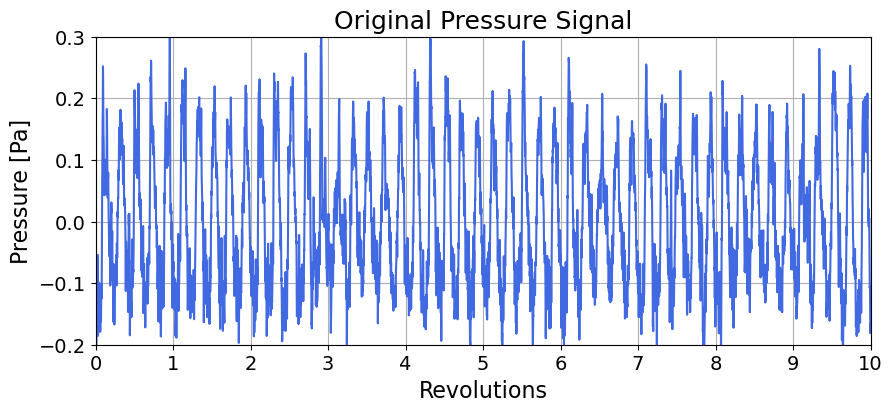

In [75]:
# Load time and pressure data
time, pressure = np.loadtxt("yaw70_U10_mic244_pressure.txt").T

rpm = 3806
period = 60 / rpm # 60 [s/min] * (1/rpm) [min/rev] = period [s/rev]
num_revs = 10
blade_pass_freq = rpm / 60 * 5 # (rpm) [rev/min] * (1/60) [min/s] * 5 [blade passages/rev] = BPF [Hz]

# Plot the original signal for a few revolutions
plt.figure(figsize=(10, 4))
plt.plot(time / period, pressure, color='royalblue', linewidth=1.5)
plt.xlim([0, num_revs])
plt.ylim([-0.2,0.3])
plt.xlabel("Revolutions", fontsize=FONT_SIZE_AXIS)
plt.ylabel("Pressure [Pa]", fontsize=FONT_SIZE_AXIS)
plt.xticks(np.arange(11), fontsize=FONT_SIZE_TICKS)
plt.yticks(fontsize=FONT_SIZE_TICKS)
plt.grid(True)
plt.title("Original Pressure Signal", fontsize=FONT_SIZE_TITLE)

## 2. Phase-Averaging the Deterministic Component
The first step is phase-averaging to separate deterministic and nondeterministic noise. This is common for rotating machinery like propellers and aircraft turbofan engines.
Time $t$ can be divided into strides of the period $T$ as:

$$ t = \tau + n T $$

where $n$ is the index of the period ($0,1, 2, ... N-1$) and $\tau$ is the time within a single revolution ($0 \le \tau < T$).

This allows the pressure $p(t)$ to be separated into the phase-averaged mean $\bar{p}(\tau)$ and residual $p'(t)$:
$$ p(\tau + nT) = \bar{p}(\tau) + p'(\tau + nT) $$

The phase-averaged signal $\bar{p}(\tau)$ is computed across all $N$ revolutions as:

$$ \bar{p}(\tau) = \frac{1}{N} \sum_{n=0}^{N-1} p(\tau + nT) $$

In Python, this is efficiently calculated by reshaping the 1D signal array into a 2D array of shape `(num_revs, samples_per_rev)` and taking the mean across the first axis. The random broadband noise averages out, leaving only the tonal component that is consistently present across all revolutions. The following plot shows the phase-averaged mean superimposed over each period of the original signal, where the vertical spread is the broadband noise.

Text(0.5, 1.0, 'Phase-Averaging of Pressure Signal')

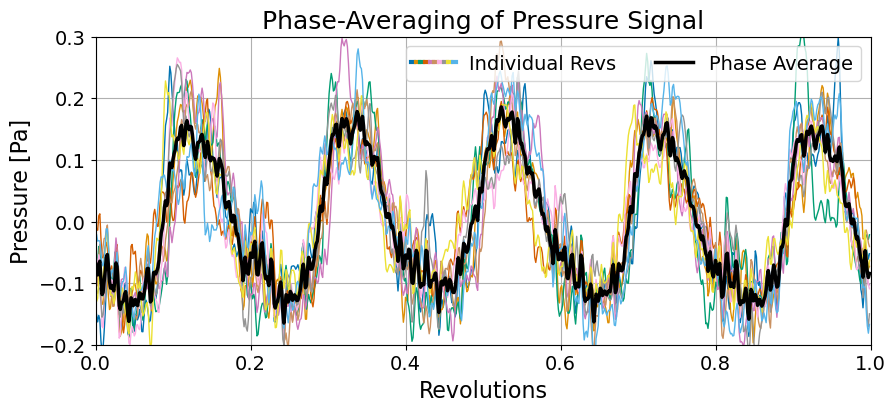

In [76]:
# There are 10 revolutions of data with 720 samples each.
samples_per_rev = 720
num_revs = 10

# Reshape so each period is in a separate row
pressure_per_rev = pressure.reshape((num_revs, samples_per_rev))

# Phase average by taking the mean across the columns (revolutions)
pressure_phase_avg = np.mean(pressure_per_rev, axis=0)

# Plot all revolutions superimposed, followed by the phase average
plt.figure(figsize=(10, 4))
time_one_rev = time[:samples_per_rev] / period

# Plot individual revolutions with a colormap
colors = sbn.color_palette("colorblind", num_revs)
lines = []
for i in range(num_revs):
    line, = plt.plot(time_one_rev, pressure_per_rev[i, :], color=colors[i])
    lines.append(line)

# Plot phase-averaged signal
line_avg, = plt.plot(time_one_rev, pressure_phase_avg, color='black', linewidth=2.5)

plt.xlim([0, 1])
plt.ylim([-0.2,0.3])
plt.xlabel("Revolutions", fontsize=FONT_SIZE_AXIS)
plt.ylabel("Pressure [Pa]", fontsize=FONT_SIZE_AXIS)
plt.xticks(fontsize=FONT_SIZE_TICKS)
plt.yticks(fontsize=FONT_SIZE_TICKS)
plt.grid(True)
# Temporarily thicken lines so the legend picks it up
for line in lines:
    line.set_linewidth(3.0)

plt.legend([tuple(lines), line_avg], ['Individual Revs', 'Phase Average'], 
           handler_map={tuple: HandlerTuple(ndivide=None)}, loc="upper right", 
           fontsize=FONT_SIZE_LEGEND, ncols=2)

# Reset lines to their original thin width
for line in lines:
    line.set_linewidth(1.0)

plt.title("Phase-Averaging of Pressure Signal", fontsize=FONT_SIZE_TITLE)

## 3. Deterministic and Nondeterministic Decomposition
The nondeterministic component can be obtained by subtracting the phase-averaged deterministic component from the total original signal.

$$ p'(t) = p(\tau + nT) - \bar{p}(\tau) $$

This is done in code by using `numpy.tile` to repeat the phase averaged pressure by the number of revs to match the original signal length, and subtracting it from the original signal. The equivalent MATLAB function is `repmat`. The following figure shows one period of the original signal and the separated deterministic and nondeterministic components.

Text(0.5, 1.0, 'Signal Decomposition (One Revolution)')

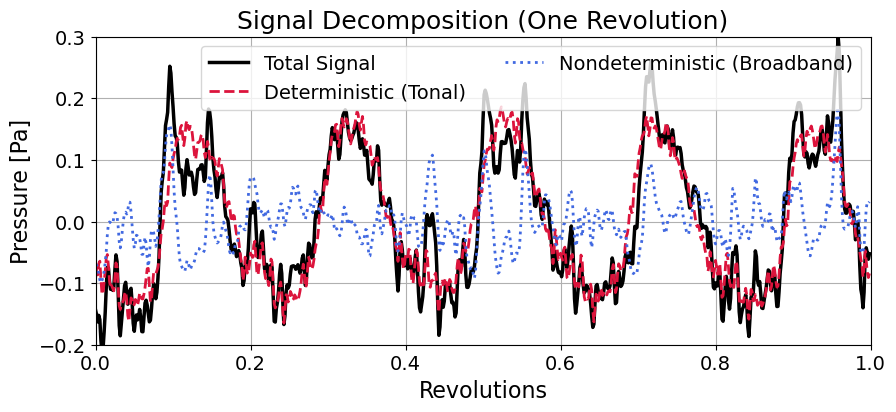

In [77]:
# Subtract per-rev average out of original pressure to get broadband component
pressure_broadband = pressure - np.tile(pressure_phase_avg, num_revs)

plt.figure(figsize=(10, 4))
plt.plot(time_one_rev, pressure[:samples_per_rev], color='black', linewidth=2.5, label='Total Signal')
plt.plot(time_one_rev, pressure_phase_avg, color='crimson', linestyle='dashed', linewidth=2, label="Deterministic (Tonal)")
plt.plot(time_one_rev, pressure_broadband[:samples_per_rev], color='royalblue', linestyle='dotted', linewidth=2, label="Nondeterministic (Broadband)")

plt.xlim([0, 1])
plt.ylim([-0.2,0.3])
plt.xlabel("Revolutions", fontsize=FONT_SIZE_AXIS)
plt.ylabel("Pressure [Pa]", fontsize=FONT_SIZE_AXIS)
plt.xticks(fontsize=FONT_SIZE_TICKS)
plt.yticks(fontsize=FONT_SIZE_TICKS)
plt.grid(True)
plt.legend(loc="upper right", fontsize=FONT_SIZE_LEGEND, ncols=2)
plt.title("Signal Decomposition (One Revolution)", fontsize=FONT_SIZE_TITLE)

## 4. Frequency Domain: FFT vs Welch's Method
Noise analysis ultimately requires examination in the frequency domain. In practice, engineers usually use Welch's method. This approach can be introduced by showing the simple case in which Welch's method is equivalent to a standard Fast Fourier Transform (FFT). *(For a refresher on FFT fundamentals, refer to the post: 
[FFT Signal Analysis using Python](https://adrozman.github.io/blog/fft-fundamentals-python/))*


First, a one-sided FFT is computed manually to obtain the spectrum of the total signal:


In [78]:
num_samples = len(pressure)
dt = time[1] - time[0]

# Manual FFT
fft_spectrum = np.fft.fft(pressure)
fft_freqs = np.fft.fftfreq(num_samples, d=dt)

# The one-sided spectrum includes DC (0 Hz) and the Nyquist frequency (if N is even).
# Total number of bins in the one-sided spectrum:
end_idx_including_nyquist = num_samples // 2 + 1
fft_onesided = np.abs(fft_spectrum[:end_idx_including_nyquist]) / num_samples
fft_freqs = fft_freqs[:end_idx_including_nyquist]

# Multiply the positive frequencies by 2 (excluding DC (0) and Nyquist frequency).
# Even-length signals include the Nyquist frequency, which should not be doubled. Odd-length signals do not.
# Using ceiling function captures the correct stop index to double, excluding Nyquist if it exists.
end_idx_excluding_nyquist = int(np.ceil(num_samples / 2))
fft_onesided[1:end_idx_excluding_nyquist] *= 2

**Welch's Method** is an approach used to estimate spectra of random data. For a long random signal, variance can be reduced by splitting the signal into $K$ overlapping segments of length $M$, and averaging the spectrum of each segment. It also includes a window function $w(n)$ multiplied to each segment to reduce spectral leakage:

$$ P_{xx}(f) = \frac{1}{K} \sum_{k=1}^{K} \left( \frac{1}{M U} \left| \sum_{n=0}^{M-1} x_k(n) w(n) e^{-j 2\pi f n} \right|^2 \right) $$

$U$ is the normalization factor discussed in the previous post which compensates for the reduction in energy by applying the window.

Using a 'boxcar' window ($w(n)=1$ so $U=1$) and a segment length $M=N$, ($N$ is the total number of samples, so the number of segments $K=1$) simplifies this to a simple FFT with no window, as was calculated to obtain `fft_freqs` above.

$$ P_{xx}(f) = \frac{1}{N} \left| \sum_{n=0}^{N-1} x(n) e^{-j 2\pi f n} \right|^2 $$

In [79]:
# Same thing using Welch's method (scaling='spectrum' for tonal amplitudes)
welch_freqs, welch_spectrum = welch(pressure, fs=1/dt, window='boxcar', nperseg=num_samples, scaling='spectrum')

Finally, the spectra are converted to **Sound Pressure Level (SPL)** in decibels. This is a logarithmic scale contextualized to human perception of noise. It uses a specific reference pressure $p_{ref} = 20 \mu\text{Pa}$ corresponding to the absolute threshold of human hearing, thus any noise with SPL below $0$ dB is too quiet to be heard by humans.

$$ SPL = 10 \log_{10} \left( \frac{\overline{p^2}}{p_{ref}^2} \right) \quad [\text{dB}] $$

Note that for the manual FFT, the raw amplitude must first be converted to Root Mean Square (RMS). Because the FFT algorithm produces a spectrum of the amplitude of sine waves, a factor of one half is included. This is done automatically within the Welch function:

$$ \overline{p^2_{sine}} = \frac{1}{2} |p|^2 $$

When these steps are taken, identical spectra are produced by the manual FFT and Welch's algorithm, as demonstrated by the figure below.

Text(0.5, 1.0, "Equivalence between FFT and Welch's Method")

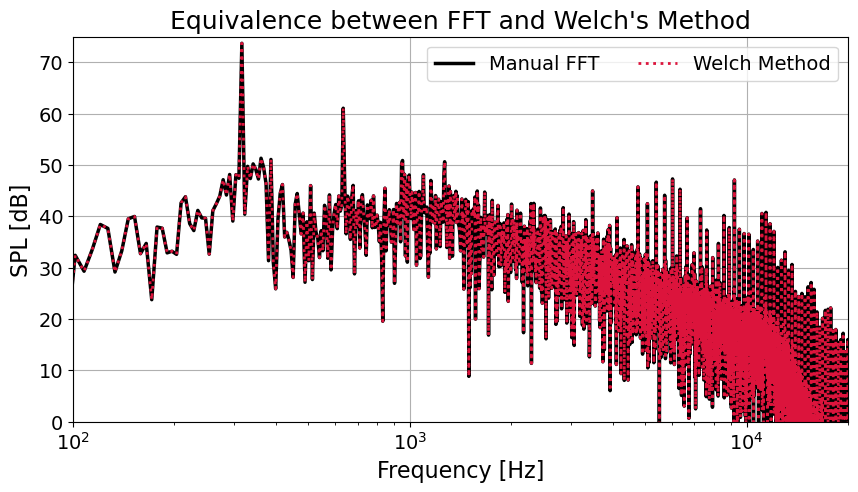

In [80]:
# FFT output is amplitude of sine waves. The RMS of a sine wave is A / sqrt(2)
# Squaring it yields the Mean Square
fft_rms_sq = 0.5 * fft_onesided**2

# Convert to decibels (Sound Pressure Level)
fft_spl = 10 * np.log10(fft_rms_sq / (2e-5)**2)
welch_spl = 10 * np.log10(welch_spectrum / (2e-5)**2)

plt.figure(figsize=(10, 5))
plt.semilogx(fft_freqs, fft_spl, color='black', linewidth=2.5, label="Manual FFT")
plt.plot(welch_freqs, welch_spl, color='crimson', linestyle='dotted', linewidth=2, label="Welch Method")
plt.ylim(0, 75)
plt.xlim(100, 20000)
plt.xlabel("Frequency [Hz]", fontsize=FONT_SIZE_AXIS)
plt.ylabel("SPL [dB]", fontsize=FONT_SIZE_AXIS)
plt.xticks(fontsize=FONT_SIZE_TICKS)
plt.yticks(fontsize=FONT_SIZE_TICKS)
plt.grid(True)
plt.legend(loc="upper right", fontsize=FONT_SIZE_LEGEND, ncols=2)
plt.title("Equivalence between FFT and Welch's Method", fontsize=FONT_SIZE_TITLE)

## 5. Window Correction Factors (Amplitude vs Energy)
From the Welch equation in Section 4, the normalization factor $U$ compensates for the energy reduction caused by the window function.
However, the correction depends on whether the noise is tonal or broadband. 
Analysis of tones that occurs at exact frequencies requires the preservation of peak amplitudes, while analysis of continuous broadband spectra requires preservation of total energy.

SciPy's `welch` function encodes this distinction directly in the `scaling` argument:

[From scipy/signal/_spectral_py.py](https://github.com/scipy/scipy/blob/main/scipy/signal/_spectral_py.py):
```python
if scaling == 'density':
    scale = 1.0 / (fs * (win*win).sum())
elif scaling == 'spectrum':
    scale = 1.0 / win.sum()**2
```

Each normalization is derived below using a Hanning window for example values.

### Amplitude Correction — `scaling='spectrum'` (Tonal Noise)
For tonal noise, energy is concentrated at discrete frequencies. The goal is to recover the true peak amplitude at each tone.
A tone at frequency $f_0$ oscillates at a single frequency, so all $N$ windowed samples add in phase in the DFT sum:
$$ \left|\sum_{n=0}^{N-1} x(n)\, w(n)\, e^{-j 2\pi f_0 n}\right| = A \sum_{n=0}^{N-1} w(n) = A\,\bar{w}\,N $$
Because the samples add in phase, the magnitude at a single bin scales with $\sum_{n} w(n)$.
Dividing the squared magnitude by $\left(\sum_{n} w(n)\right)^2$ recovers $A^2$. This is `1 / win.sum()**2` in the SciPy source code.
For a Hanning window with $\bar{w} = 0.5$, the correction factor is $\sqrt{1/0.5^2} = \mathbf{2}$.

### Energy Correction — `scaling='density'` (Broadband Noise)
For broadband noise, energy is spread across all frequencies. The goal is to preserve the total signal energy (variance).
When frequency contributions are independent, their *powers* (not amplitudes) add, so the total energy across all bins scales
with $\sum_{n} w(n)^2$.
Dividing by $\sum_{n} w(n)^2$ recovers the true total energy, and dividing by $f_s$ converts to density
(power per Hz), giving `1 / (fs * (win*win).sum())` from the SciPy source code.
For a Hanning window with $\sum_{n} w(n)^2 = \frac{3}{8}N$, the correction factor is $\sqrt{8/3} \approx \mathbf{1.63}$.

### Summary
| `scaling` | What it preserves | Power normalization | Hanning correction |
|---|---|---|---|
| `'spectrum'` | Peak amplitude of discrete tones | $\left(\sum_n w(n)\right)^2$ | $2.0$ |
| `'density'` | Total integrated energy | $\sum_n w(n)^2$ | $\approx 1.63$ |

Because these correction factors differ ($2.0 \neq 1.63$), the two scaling options are not interchangeable.
Even if a `density` scaling output is multiplied by the bin width $\Delta f$ to recover SPL, the result will
still underpredict the peak amplitude of a discrete tone by $20\log_{10}(2.0/1.63) \approx 1.76\ \text{dB}$.
This is demonstrated in the figure below.

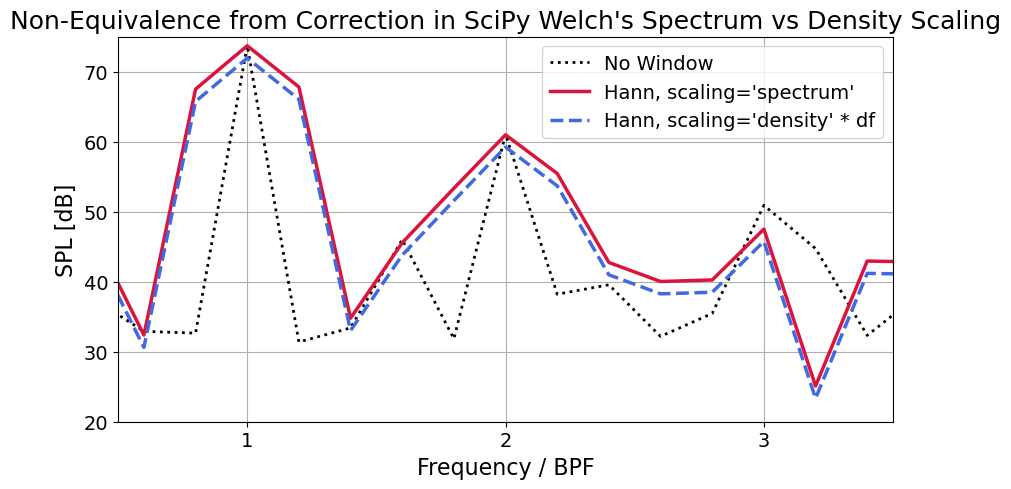

In [81]:
# It can be proven why `scaling='spectrum'` must be used for tones instead of `scaling='density'`.
# Even if one attempts to integrate the density (dB/Hz) back into power (dB) by multiplying by the 
# bin width (df), the windowing correction factors are fundamentally different!
# The energy correction (1.63) is smaller than the amplitude correction (2.0), meaning the 
# density formulation will underpredict the peak of a deterministic tone by ~1.76 dB.

freqs_tonal, spec_tonal_no_window = welch(pressure_phase_avg, fs=1/dt, window='box', 
                                nperseg=samples_per_rev, scaling='spectrum')

_, spec_tonal1 = welch(pressure_phase_avg, fs=1/dt, window='hann', 
                                nperseg=samples_per_rev, scaling='spectrum')

_, spec_tonal2 = welch(pressure_phase_avg, fs=1/dt, window='hann', 
                                nperseg=samples_per_rev, scaling='density')

spl_tonal_no_window = 10 * np.log10(spec_tonal_no_window / (2e-5)**2)
spl_tonal_spectrum = 10 * np.log10(spec_tonal1 / (2e-5)**2)

# Multiply density (V^2/Hz) by df (Hz) to get power (V^2), then convert to SPL
df = freqs_tonal[1]
spl_tonal_density_integrated = 10 * np.log10(spec_tonal2 * df / (2e-5)**2)


plt.figure(figsize=(10, 5))
plt.plot(freqs_tonal / blade_pass_freq, spl_tonal_no_window, color='black', linestyle='dotted', 
         linewidth=2, label="No Window")
plt.plot(freqs_tonal / blade_pass_freq, spl_tonal_spectrum, color='crimson', 
         linewidth=2.5, label="Hann, scaling='spectrum'")
plt.plot(freqs_tonal / blade_pass_freq, spl_tonal_density_integrated, color='royalblue', 
         linewidth=2.5, linestyle='dashed', label="Hann, scaling='density' * df")


plt.xlim((0.5, 3.5))
plt.ylim((20, 75))
plt.xticks(np.arange(1, 4), fontsize=FONT_SIZE_TICKS)
plt.yticks(fontsize=FONT_SIZE_TICKS)
plt.xlabel("Frequency / BPF", fontsize=FONT_SIZE_AXIS)
plt.ylabel("SPL [dB]", fontsize=FONT_SIZE_AXIS)
plt.title("Non-Equivalence from Correction in SciPy Welch's Spectrum vs Density Scaling", fontsize=FONT_SIZE_TITLE)
plt.grid(True)
plt.legend(loc="upper right", fontsize=FONT_SIZE_LEGEND)
plt.show()

## 6. Comparing Tonal Extract to Total Signal
To analyze rotating machinery it is common to look at multiples of the *Blade Passage Frequency* (BPF) $f*N_{blades}$, which will be the frequencies of the tonal noise peaks. The Sound Power Level (SPL) metric is used since the amplitude of the discrete tones is the interest.

Below, the SPL of the total signal's $p(t)$ is compared to the peaks of the SPL of the phase-averaged tonal noise $\bar{p}(\tau)$.

Text(0.5, 1.0, 'Tonal Peaks vs Total Signal')

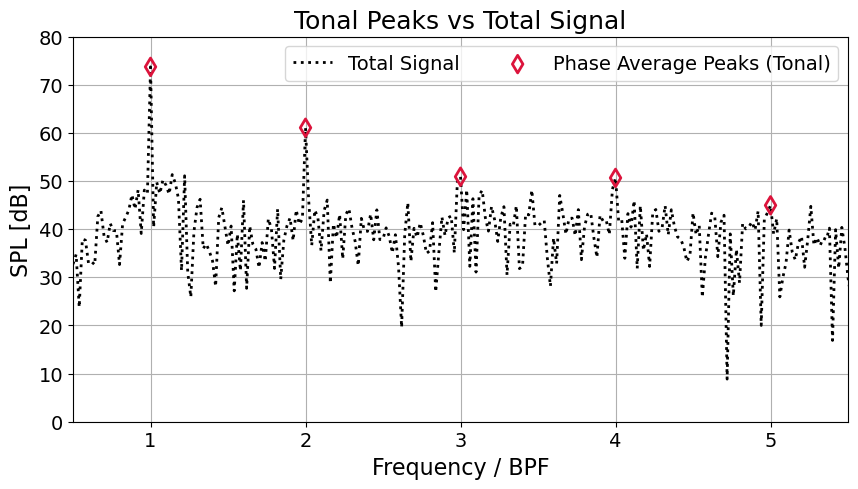

In [82]:
freqs_tonal, spec_tonal = welch(pressure_phase_avg, fs=1/dt, window='boxcar', 
                                nperseg=samples_per_rev, scaling='spectrum')
spl_tonal = 10 * np.log10(spec_tonal / (2e-5)**2)

# Extract just the peaks at the BPF harmonics
# BPF is 5 times the fundamental rotation frequency. The frequency resolution df is exactly the rotation frequency.
# Therefore, the BPF harmonics are located at indices 5, 10, 15, 20, 25...
bpf_indices = np.arange(5, len(freqs_tonal), 5)
bpf_harmonics = freqs_tonal[bpf_indices]
spl_bpf_peaks = spl_tonal[bpf_indices]

plt.figure(figsize=(10, 5))
plt.plot(welch_freqs / blade_pass_freq, welch_spl, color='black', linestyle='dotted', linewidth=2, label='Total Signal')
plt.scatter(bpf_harmonics / blade_pass_freq, spl_bpf_peaks, c='None', edgecolors='crimson', s=80, linewidths=2, zorder=5, 
            label='Phase Average Peaks (Tonal)',marker='d')

plt.ylim(0, 80)
plt.xlim(0.5, 5.5)
plt.xticks(np.arange(1, 6), fontsize=FONT_SIZE_TICKS)
plt.yticks(fontsize=FONT_SIZE_TICKS)
plt.xlabel("Frequency / BPF", fontsize=FONT_SIZE_AXIS)
plt.ylabel("SPL [dB]", fontsize=FONT_SIZE_AXIS)
plt.grid(True)
plt.legend(loc="upper right", fontsize=FONT_SIZE_LEGEND, ncols=2)
plt.title("Tonal Peaks vs Total Signal", fontsize=FONT_SIZE_TITLE)

## 7. Comparing Broadband Extract to Total Signal

Because broadband noise occurs at continuous frequencies across the spectrum, **Power Spectral Density (PSD)** metric is used which describes the power
contained along each frequency bin. If SPL is used, which does not normalize by the bin width, amplitudes vary depending on the 
frequency resolution. The independence with respect to frequency resolution makes PSD ideal to display continuous broadband noise.

$$ PSD = 10 \log_{10} \left( \frac{\overline{p^2} }{\Delta f~p_{ref}^2} \right) \quad [\text{dB/Hz}] $$

### Welch's Method Features that are Convenient for Broadband Noise Analysis

Unlike the Welch calculation for the tonal spectrum which used a single segment of the entire signal length, the broadband
analysis uses the full capability of Welch's method by splitting the signal into multiple overlapping segments.
This was not necessary for the tonal noise since the averaging was performed in the time domain.

When the signal is split into $K$ segments, each segment produces an independent estimate of the PSD. Averaging
these $K$ estimates reduces the variance of the result. SciPy defaults to 50% overlap between segments, 
which nearly doubles $K$ for a given record length.
A Hanning window is also applied to each segment to reduce spectral leakage from the broadband energy.
The figure below demonstrates the effect of averaging these spectra on reducing the variance of the broadband signal $p'$.

Text(0.5, 1.0, "Variance Reduction by Welch's Method using Multiple Segments")

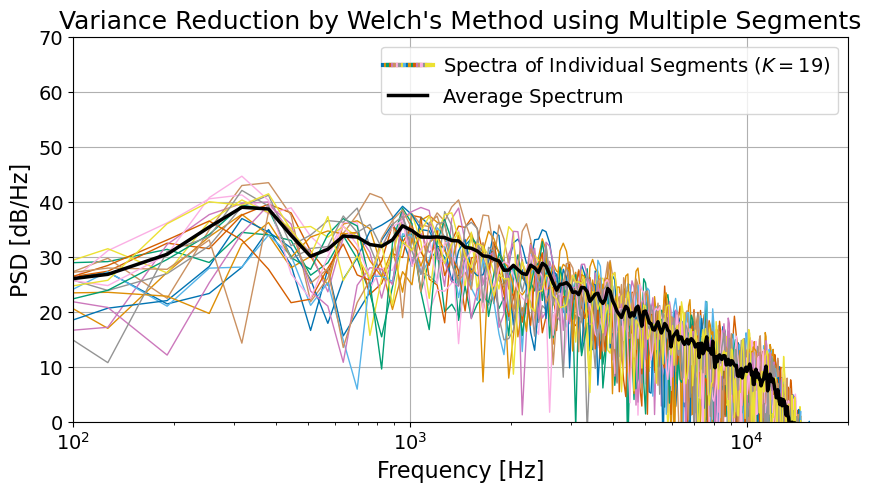

In [86]:
# Compute the PSD for every individual overlapping segment
freqs_seg, times_seg, psd_segments_raw = spectrogram(pressure_broadband, fs=1/dt, window='hann', 
                                                     nperseg=samples_per_rev, noverlap=samples_per_rev//2, 
                                                     scaling='density')
psd_segments = 10 * np.log10(psd_segments_raw / (2e-5)**2)

# The Welch estimate is simply the average of these individual segment PSDs
psd_welch_avg = 10 * np.log10(np.mean(psd_segments_raw, axis=-1) / (2e-5)**2)
K_segments = psd_segments.shape[1]

plt.figure(figsize=(10, 5))

# Plot all individual segments using a colormap
colors = sbn.color_palette("colorblind", K_segments)
lines = []
for i in range(K_segments):
    line, = plt.semilogx(freqs_seg, psd_segments[:, i], color=colors[i])
    lines.append(line)

# Plot the Welch averaged PSD
line_avg, = plt.semilogx(freqs_seg, psd_welch_avg, color='black', linewidth=2.5)

plt.ylim(0, 70)
plt.xlim(100, 20000)
plt.xlabel("Frequency [Hz]", fontsize=FONT_SIZE_AXIS)
plt.ylabel("PSD [dB/Hz]", fontsize=FONT_SIZE_AXIS)
plt.xticks(fontsize=FONT_SIZE_TICKS)
plt.yticks(fontsize=FONT_SIZE_TICKS)
plt.grid(True)

# Temporarily thicken lines so the legend picks it up
for line in lines:
    line.set_linewidth(3.0)

plt.legend([tuple(lines), line_avg], [f'Spectra of Individual Segments ($K={K_segments}$)', 'Average Spectrum'], 
           handler_map={tuple: HandlerTuple(ndivide=None)}, loc="upper right", 
           fontsize=FONT_SIZE_LEGEND)

# Reset lines to their original thin width
for line in lines:
    line.set_linewidth(1.0)
    
plt.title("Variance Reduction by Welch's Method using Multiple Segments", fontsize=FONT_SIZE_TITLE)

Finally, the averaged PSD of broadband $p'$ using Welch's method is compared to the total signal in the figure below. The peaks at the BPF harmonics have been removed.

Text(0.5, 1.0, 'Broadband vs Total Signal')

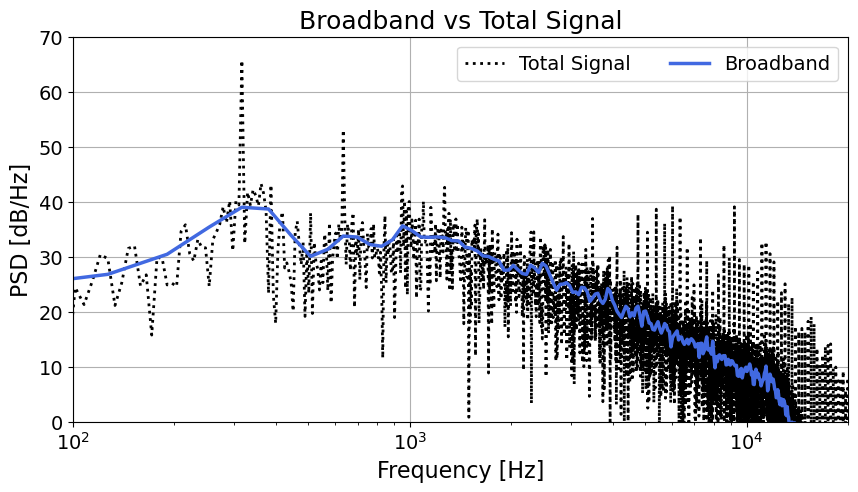

In [89]:
# Welch's method (scaling='density' for Power Spectral Density)
welch_freqs, welch_psd_raw = welch(pressure, fs=1/dt, window='boxcar', nperseg=num_samples, scaling='density')

welch_psd = 10 * np.log10(welch_psd_raw / (2e-5)**2)

freqs_bb, spec_broadband = welch(pressure_broadband, fs=1/dt, window='hann', nperseg=samples_per_rev, scaling='density')
psd_broadband = 10 * np.log10(spec_broadband / (2e-5)**2)

plt.figure(figsize=(10, 5))
plt.semilogx(welch_freqs, welch_psd, color='black', linestyle='dotted', linewidth=2, label='Total Signal')
plt.semilogx(freqs_bb, psd_broadband, color='royalblue', linewidth=2.5, label='Broadband')
plt.ylim(0, 70)
plt.xlim(100, 20000)
plt.xlabel("Frequency [Hz]", fontsize=FONT_SIZE_AXIS)
plt.ylabel("PSD [dB/Hz]", fontsize=FONT_SIZE_AXIS)
plt.xticks(fontsize=FONT_SIZE_TICKS)
plt.yticks(fontsize=FONT_SIZE_TICKS)
plt.grid(True)
plt.legend(loc="upper right", fontsize=FONT_SIZE_LEGEND, ncols=2)
plt.title("Broadband vs Total Signal", fontsize=FONT_SIZE_TITLE)

